📊 Sprint 2 – Exploratory Data Analysis & Visualization

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

dff = pd.read_csv('Flight_Delays_50K_cleaned.csv', parse_dates=['FLIGHT_DATE'])
print(dff.shape)

(50000, 35)


In [41]:
for c in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON', 'TAIL_NUMBER',
          'ORIGIN_CODE_FORMAT', 'DEST_CODE_FORMAT']:
    dff[c] = dff[c].astype('category')

dff.dtypes

YEAR                            int64
MONTH                           int64
DAY                             int64
DAY_OF_WEEK                     int64
AIRLINE                      category
FLIGHT_NUMBER                   int64
TAIL_NUMBER                  category
ORIGIN_AIRPORT               category
DESTINATION_AIRPORT          category
SCHEDULED_DEPARTURE             int64
DEPARTURE_TIME                 object
DEPARTURE_DELAY               float64
TAXI_OUT                      float64
WHEELS_OFF                    float64
SCHEDULED_TIME                float64
ELAPSED_TIME                  float64
AIR_TIME                      float64
DISTANCE                        int64
WHEELS_ON                     float64
TAXI_IN                       float64
SCHEDULED_ARRIVAL               int64
ARRIVAL_TIME                  float64
ARRIVAL_DELAY                 float64
DIVERTED                        int64
CANCELLED                       int64
CANCELLATION_REASON          category
AIR_SYSTEM_D

Step 1: Descriptive Analysis

In [42]:
num_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
            'ELAPSED_TIME', 'SCHEDULED_TIME', 'DISTANCE',
            'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
            'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

In [43]:
central = pd.DataFrame({
    'mean':   dff[num_cols].mean(),
    'median': dff[num_cols].median(),
    'mode':   dff[num_cols].mode().iloc[0]
}).round(2)
central

,mean,median,mode
DEPARTURE_DELAY,9.09,-2.0,-3.0
ARRIVAL_DELAY,4.00,-5.0,-10.0
TAXI_OUT,16.02,14.0,11.0
TAXI_IN,7.41,6.0,4.0
AIR_TIME,113.81,94.0,63.0
ELAPSED_TIME,137.22,118.0,76.0
SCHEDULED_TIME,141.92,123.0,85.0
DISTANCE,824.20,646.0,337.0
AIR_SYSTEM_DELAY,2.41,0.0,0.0
SECURITY_DELAY,0.01,0.0,0.0


In [44]:

q1 = dff[num_cols].quantile(0.25)
q3 = dff[num_cols].quantile(0.75)

dispersion = pd.DataFrame({
    'std':      dff[num_cols].std(),
    'variance': dff[num_cols].var(),
    'min':      dff[num_cols].min(),
    'max':      dff[num_cols].max(),
    'range':    dff[num_cols].max() - dff[num_cols].min(),
    'IQR':      q3 - q1
}).round(2)
dispersion

,std,variance,min,max,range,IQR
DEPARTURE_DELAY,35.46,1257.75,-55.0,1515.0,1570.0,12.0
ARRIVAL_DELAY,37.75,1425.44,-70.0,1574.0,1644.0,21.0
TAXI_OUT,8.81,77.54,1.0,149.0,148.0,8.0
TAXI_IN,5.61,31.49,1.0,165.0,164.0,5.0
AIR_TIME,72.56,5264.86,9.0,654.0,645.0,83.0
ELAPSED_TIME,74.55,5557.03,17.0,715.0,698.0,87.0
SCHEDULED_TIME,75.60,5714.96,21.0,679.0,658.0,89.0
DISTANCE,611.89,374407.33,31.0,4983.0,4952.0,693.0
AIR_SYSTEM_DELAY,12.53,156.98,0.0,532.0,532.0,0.0
SECURITY_DELAY,0.77,0.59,0.0,129.0,129.0,0.0


In [45]:
shape = pd.DataFrame({
    'skewness': dff[num_cols].skew(),
    'kurtosis': dff[num_cols].kurt()
}).round(2)
shape

,skewness,kurtosis
DEPARTURE_DELAY,7.27,125.86
ARRIVAL_DELAY,6.39,109.38
TAXI_OUT,3.39,23.00
TAXI_IN,5.42,67.91
AIR_TIME,1.41,2.37
ELAPSED_TIME,1.38,2.32
SCHEDULED_TIME,1.37,2.17
DISTANCE,1.45,2.48
AIR_SYSTEM_DELAY,12.10,249.41
SECURITY_DELAY,113.49,16978.10


Mean and median disagree sharply on delays, so "average delay" is a misleading headline number.
Late aircraft and airline-controlled causes dominate delay minutes, and weather is a small share.

Step 2: Univariate Analysis

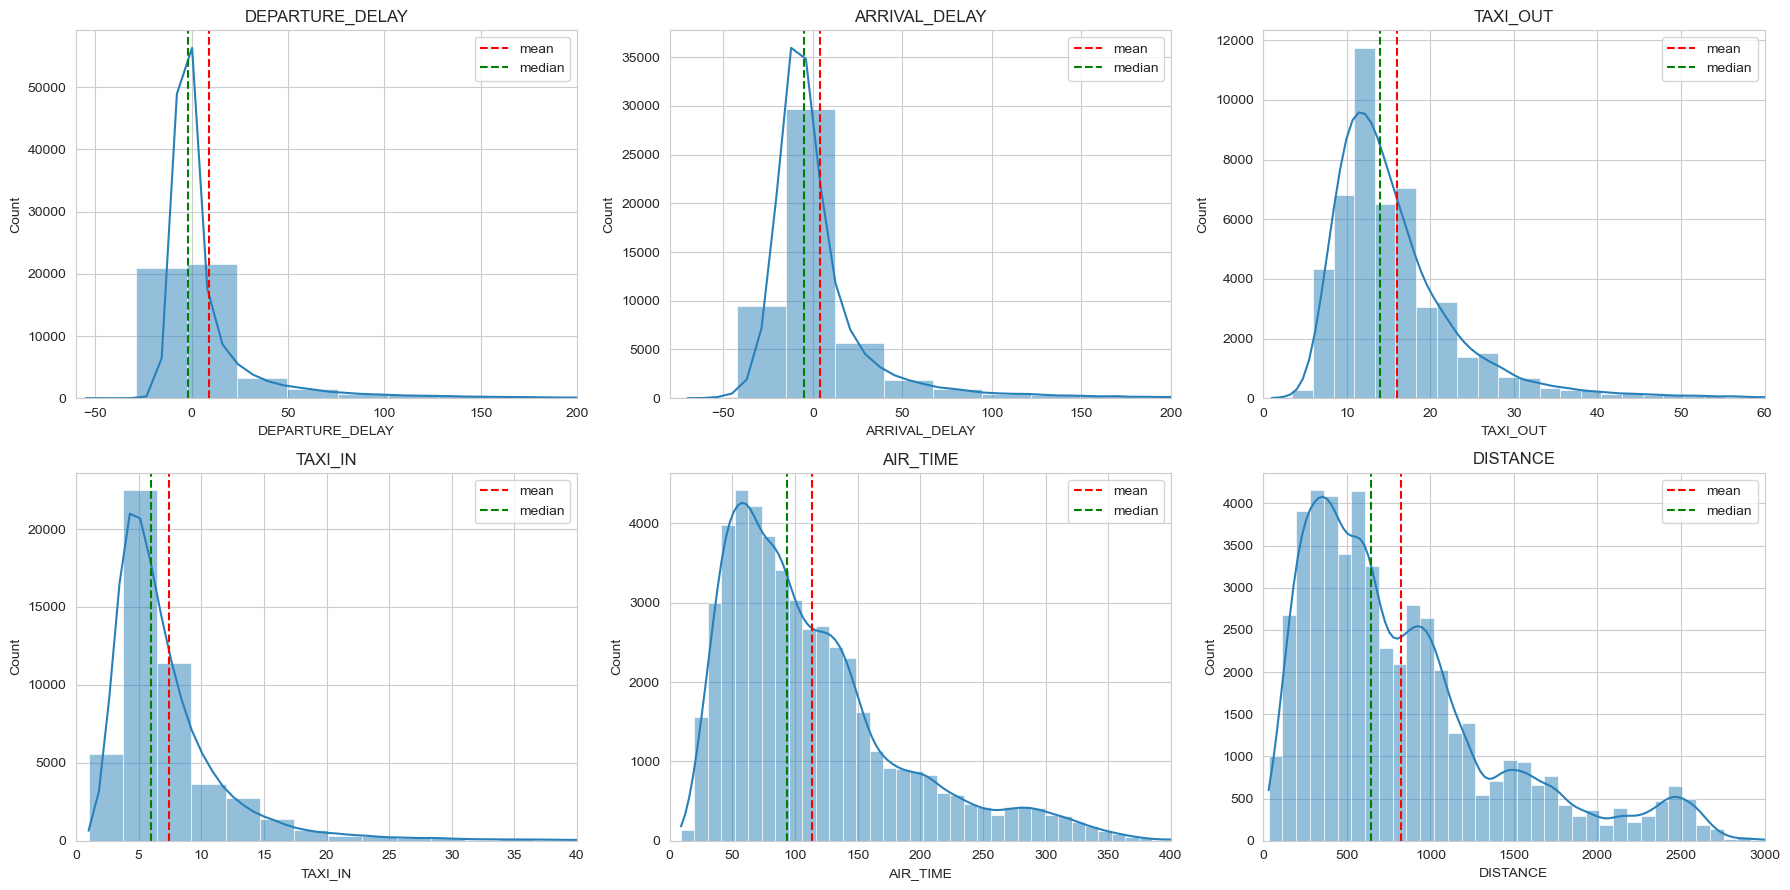

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

cols_ranges = [
    ('DEPARTURE_DELAY', (-60, 200)),
    ('ARRIVAL_DELAY',   (-80, 200)),
    ('TAXI_OUT',        (0, 60)),
    ('TAXI_IN',         (0, 40)),
    ('AIR_TIME',        (0, 400)),
    ('DISTANCE',        (0, 3000)),
]

for ax, (col, rng) in zip(axes.flat, cols_ranges):
    sns.histplot(dff[col].dropna(), bins=60, kde=True, ax=ax, color='#2980b9')
    ax.set_xlim(rng)
    ax.axvline(dff[col].mean(),   color='red',   linestyle='--', label='mean')
    ax.axvline(dff[col].median(), color='green', linestyle='--', label='median')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [47]:
for col in ['AIRLINE', 'CANCELLATION_REASON', 'CANCELLED', 'DIVERTED', 'DAY_OF_WEEK', 'MONTH']:
    print(f"--- {col} ---")
    print(dff[col].value_counts())
    print(dff[col].value_counts(normalize=True).round(4) * 100)
    print()

--- AIRLINE ---
AIRLINE
WN    10946
DL     7488
AA     6208
OO     4993
EV     4969
UA     4344
MQ     2559
B6     2319
US     1701
AS     1515
NK      990
F9      750
HA      678
VX      540
Name: count, dtype: int64
AIRLINE
WN    21.89
DL    14.98
AA    12.42
OO     9.99
EV     9.94
UA     8.69
MQ     5.12
B6     4.64
US     3.40
AS     3.03
NK     1.98
F9     1.50
HA     1.36
VX     1.08
Name: proportion, dtype: float64

--- CANCELLATION_REASON ---
CANCELLATION_REASON
NOT_CANCELLED    49206
B                  432
A                  215
C                  146
D                    1
Name: count, dtype: int64
CANCELLATION_REASON
NOT_CANCELLED    98.41
B                 0.86
A                 0.43
C                 0.29
D                 0.00
Name: proportion, dtype: float64

--- CANCELLED ---
CANCELLED
0    49206
1      794
Name: count, dtype: int64
CANCELLED
0    98.41
1     1.59
Name: proportion, dtype: float64

--- DIVERTED ---
DIVERTED
0    49879
1      121
Name: count, dtype: int6

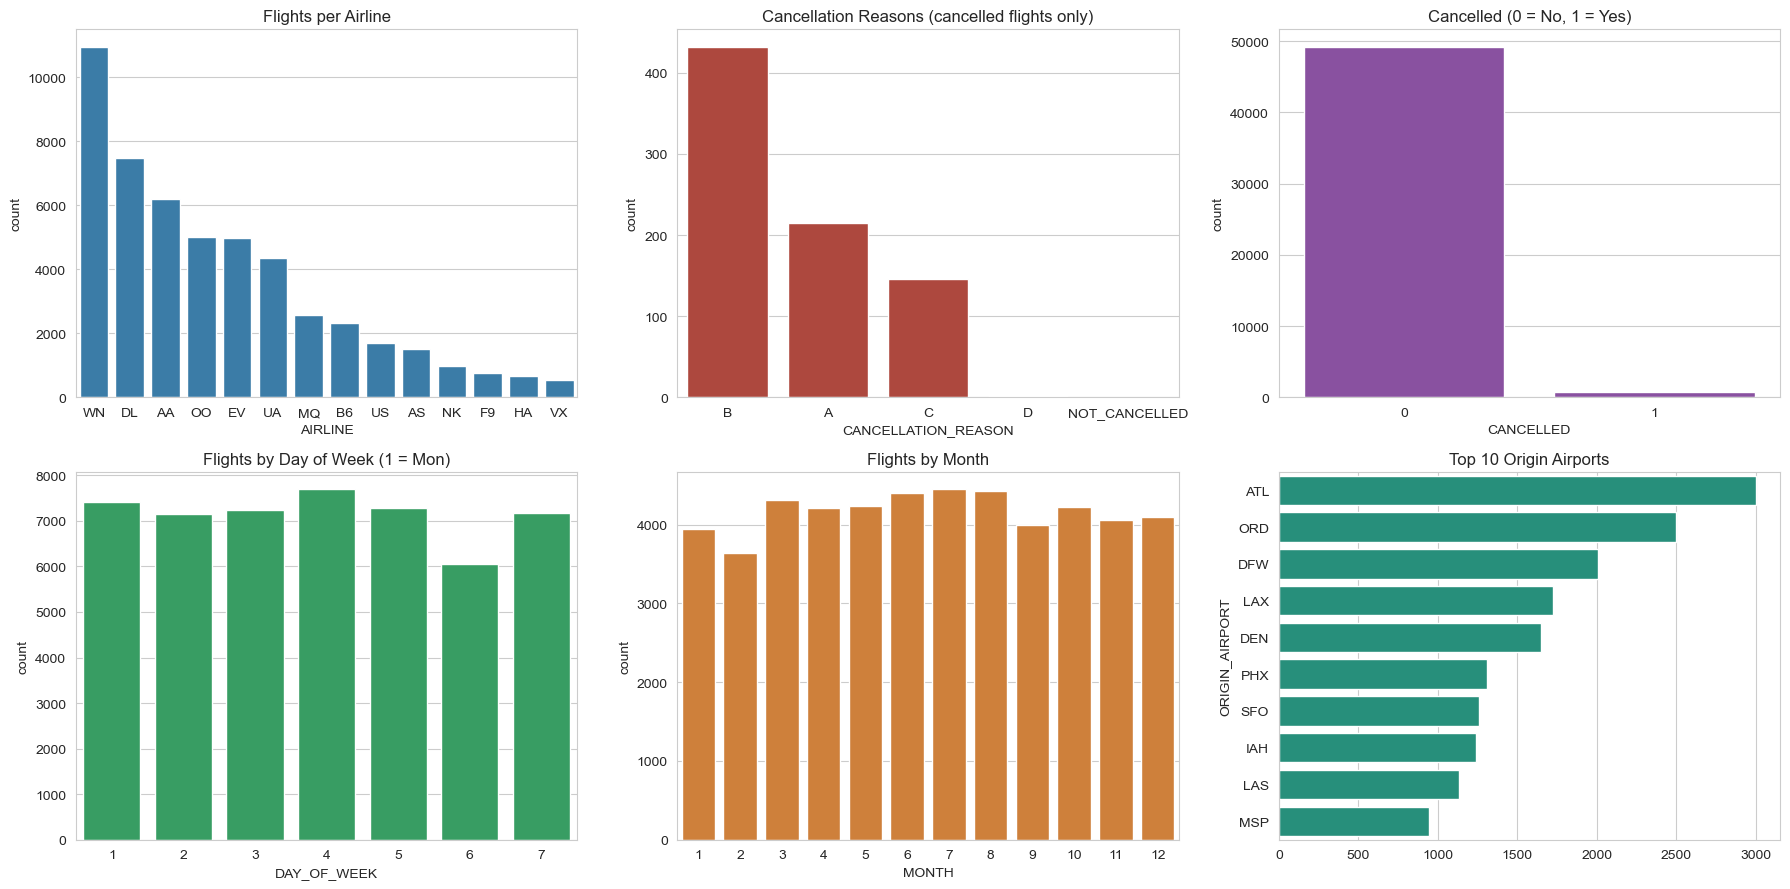

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

sns.countplot(data=dff, x='AIRLINE', order=dff['AIRLINE'].value_counts().index, ax=axes[0, 0], color='#2980b9')
axes[0, 0].set_title('Flights per Airline')

cancelled_reasons = dff[dff['CANCELLED'] == 1]['CANCELLATION_REASON']
sns.countplot(x=cancelled_reasons, order=cancelled_reasons.value_counts().index, ax=axes[0, 1], color='#c0392b')
axes[0, 1].set_title('Cancellation Reasons (cancelled flights only)')

sns.countplot(data=dff, x='CANCELLED', ax=axes[0, 2], color='#8e44ad')
axes[0, 2].set_title('Cancelled (0 = No, 1 = Yes)')

sns.countplot(data=dff, x='DAY_OF_WEEK', ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('Flights by Day of Week (1 = Mon)')

sns.countplot(data=dff, x='MONTH', ax=axes[1, 1], color='#e67e22')
axes[1, 1].set_title('Flights by Month')

top_origins = dff['ORIGIN_AIRPORT'].value_counts().head(10)
sns.barplot(x=top_origins.values, y=top_origins.index.astype(str), ax=axes[1, 2], color='#16a085')
axes[1, 2].set_title('Top 10 Origin Airports')

plt.tight_layout()
plt.show()

Step 3: Bivariate Analysis (part 1: Airline)

In [49]:
airline_delay = (dff.groupby('AIRLINE', observed=True)['ARRIVAL_DELAY']
                 .agg(flights='count', mean='mean', median='median', std='std')
                 .round(2)
                 .sort_values('mean', ascending=False))
airline_delay

,flights,mean,median,std
AIRLINE,,,,
NK,977,14.51,2.0,42.73
F9,741,10.40,-3.0,41.02
VX,537,7.04,-3.0,42.92
EV,4802,6.51,-4.0,39.68
MQ,2423,6.50,-6.0,39.48
B6,2274,5.86,-5.0,40.23
OO,4884,5.10,-4.0,38.17
WN,10796,4.39,-4.0,32.57
UA,4277,4.34,-6.0,43.52


In [50]:
airline_cancel = (dff.groupby('AIRLINE', observed=True)
                  .agg(total_flights=('CANCELLED', 'size'),
                       cancelled=('CANCELLED', 'sum')))
airline_cancel['cancel_rate_%'] = (airline_cancel['cancelled'] / airline_cancel['total_flights'] * 100).round(2)
airline_cancel = airline_cancel.sort_values('cancel_rate_%', ascending=False)
airline_cancel

,total_flights,cancelled,cancel_rate_%
AIRLINE,,,
MQ,2559,131,5.12
EV,4969,150,3.02
US,1701,34,2.00
OO,4993,95,1.90
AA,6208,104,1.68
B6,2319,39,1.68
UA,4344,59,1.36
WN,10946,127,1.16
NK,990,11,1.11


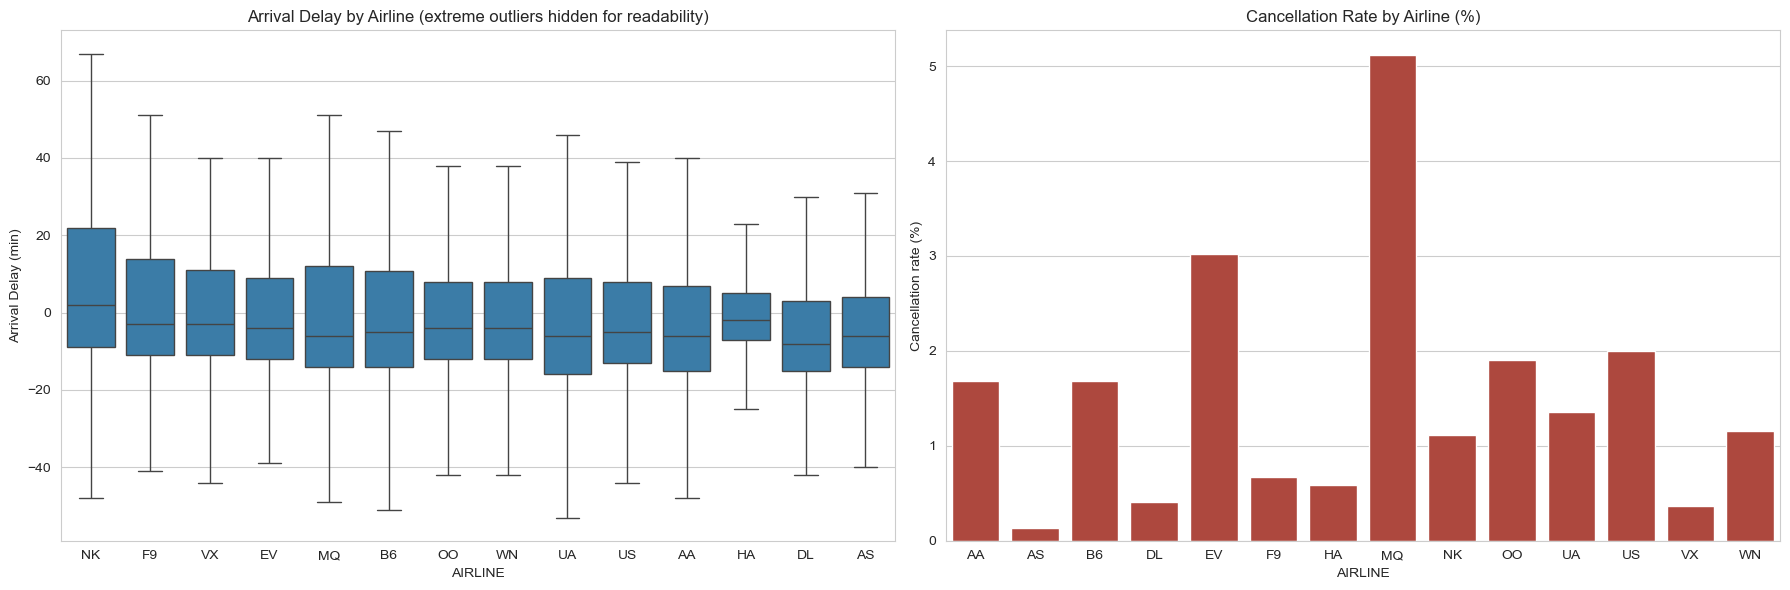

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=dff, x='AIRLINE', y='ARRIVAL_DELAY', order=airline_delay.index,
            showfliers=False, ax=axes[0], color='#2980b9')
axes[0].set_title('Arrival Delay by Airline (extreme outliers hidden for readability)')
axes[0].set_ylabel('Arrival Delay (min)')

sns.barplot(x=airline_cancel.index, y=airline_cancel['cancel_rate_%'], ax=axes[1], color='#c0392b')
axes[1].set_title('Cancellation Rate by Airline (%)')
axes[1].set_ylabel('Cancellation rate (%)')

plt.tight_layout()
plt.show()

Step 3, part 2: Departure Delay vs Arrival Delay

In [52]:
sub = dff[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].dropna()

pearson_r, _ = stats.pearsonr(sub['DEPARTURE_DELAY'], sub['ARRIVAL_DELAY'])
spearman_r, _ = stats.spearmanr(sub['DEPARTURE_DELAY'], sub['ARRIVAL_DELAY'])

print(f"Flights used: {len(sub):,}")
print(f"Pearson r  : {pearson_r:.3f}")
print(f"Spearman r : {spearman_r:.3f}")

Flights used: 49,085
Pearson r  : 0.941
Spearman r : 0.638


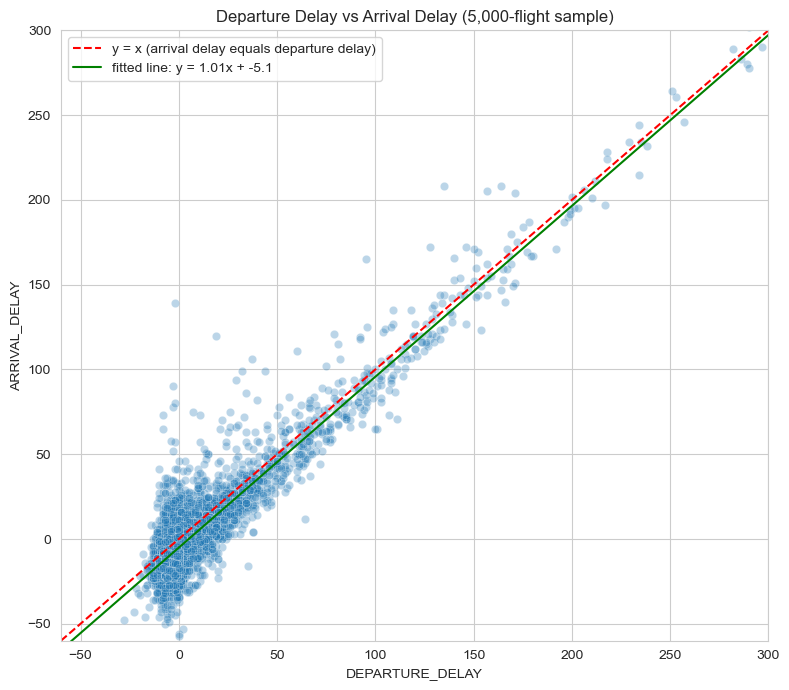

In [53]:
sample = sub.sample(5000, random_state=42)
slope, intercept, r, p, se = stats.linregress(sub['DEPARTURE_DELAY'], sub['ARRIVAL_DELAY'])
lims = np.array([-60, 300])

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=sample, x='DEPARTURE_DELAY', y='ARRIVAL_DELAY', alpha=0.3, ax=ax)
ax.plot(lims, lims, color='red', linestyle='--', label='y = x (arrival delay equals departure delay)')
ax.plot(lims, intercept + slope * lims, color='green', label=f'fitted line: y = {slope:.2f}x + {intercept:.1f}')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Departure Delay vs Arrival Delay (5,000-flight sample)')
ax.legend()
plt.tight_layout()
plt.show()

Step 3, part 3: Airport vs Delay, and Distance vs Delay

In [54]:
iata = dff[dff['ORIGIN_CODE_FORMAT'] == 'IATA']

airport_delay = (iata.groupby('ORIGIN_AIRPORT', observed=True)
                 .agg(flights=('FLIGHT_NUMBER', 'size'),
                      mean_dep_delay=('DEPARTURE_DELAY', 'mean'),
                      median_dep_delay=('DEPARTURE_DELAY', 'median'),
                      mean_arr_delay=('ARRIVAL_DELAY', 'mean'),
                      cancel_rate_pct=('CANCELLED', lambda s: s.mean() * 100)))

airport_delay = airport_delay[airport_delay['flights'] >= 200].round(2)
print("Airports with >= 200 flights:", len(airport_delay))

print("\nWorst 10 by mean departure delay:")
print(airport_delay.sort_values('mean_dep_delay', ascending=False).head(10))
print("\nBest 10:")
print(airport_delay.sort_values('mean_dep_delay').head(10))

Airports with >= 200 flights: 49

Worst 10 by mean departure delay:
                flights  mean_dep_delay  median_dep_delay  mean_arr_delay  \
ORIGIN_AIRPORT                                                              
BWI                 783           15.86               2.0            9.72   
IAD                 278           15.43               0.0            7.79   
ORD                2501           13.89              -1.0            8.02   
EWR                 880           13.77               0.0            3.53   
LGA                 854           13.10              -2.0            6.34   
FLL                 629           12.60              -2.0            6.29   
DEN                1649           12.48               0.0            7.82   
LAS                1136           12.33               0.0            7.23   
HOU                 447           12.09               1.0            7.90   
MDW                 740           11.81               0.0            5.07   

       

In [55]:
bands = pd.cut(dff['DISTANCE'],
               bins=[0, 250, 500, 1000, 1500, 2500, 5000],
               labels=['<250', '250-500', '500-1000', '1000-1500', '1500-2500', '2500+'])

distance_delay = (dff.groupby(bands, observed=True)
                  .agg(flights=('FLIGHT_NUMBER', 'size'),
                       mean_arr_delay=('ARRIVAL_DELAY', 'mean'),
                       median_arr_delay=('ARRIVAL_DELAY', 'median'),
                       cancel_rate_pct=('CANCELLED', lambda s: s.mean() * 100))
                  .round(2))
print(distance_delay)

sub = dff[['DISTANCE', 'ARRIVAL_DELAY']].dropna()
print("\nSpearman:", round(stats.spearmanr(sub['DISTANCE'], sub['ARRIVAL_DELAY'])[0], 3))

           flights  mean_arr_delay  median_arr_delay  cancel_rate_pct
DISTANCE                                                             
<250          6401            4.75              -4.0             2.39
250-500      11947            4.89              -4.0             2.03
500-1000     17427            4.16              -5.0             1.47
1000-1500     7400            4.64              -5.0             1.31
1500-2500     5782            0.23              -7.0             0.61
2500+         1043            3.15              -6.0             0.86

Spearman: -0.07


step 3 (final part): Month vs Delay and Day of Week vs Delay

In [56]:
def summarize(col):
    return (dff.groupby(col)
            .agg(flights=('FLIGHT_NUMBER', 'size'),
                 mean_arr_delay=('ARRIVAL_DELAY', 'mean'),
                 median_arr_delay=('ARRIVAL_DELAY', 'median'),
                 pct_delayed_15=('ARRIVAL_DELAY', lambda s: (s.dropna() >= 15).mean() * 100),
                 cancel_rate_pct=('CANCELLED', lambda s: s.mean() * 100))
            .round(2))

month_delay = summarize('MONTH')
dow_delay = summarize('DAY_OF_WEEK')
print(month_delay)
print(dow_delay)

       flights  mean_arr_delay  median_arr_delay  pct_delayed_15  \
MONTH                                                              
1         3942            5.76              -4.0           20.75   
2         3639            9.77              -2.0           24.13   
3         4317            4.05              -4.0           18.89   
4         4213            2.47              -5.0           16.46   
5         4236            2.85              -5.0           16.89   
6         4406            9.48              -3.0           24.86   
7         4446            5.74              -4.0           20.92   
8         4423            4.26              -5.0           18.67   
9         3998           -0.57              -7.0           13.47   
10        4228           -1.30              -7.0           12.64   
11        4059            1.10              -6.0           15.37   
12        4093            4.95              -5.0           19.93   

       cancel_rate_pct  
MONTH                 

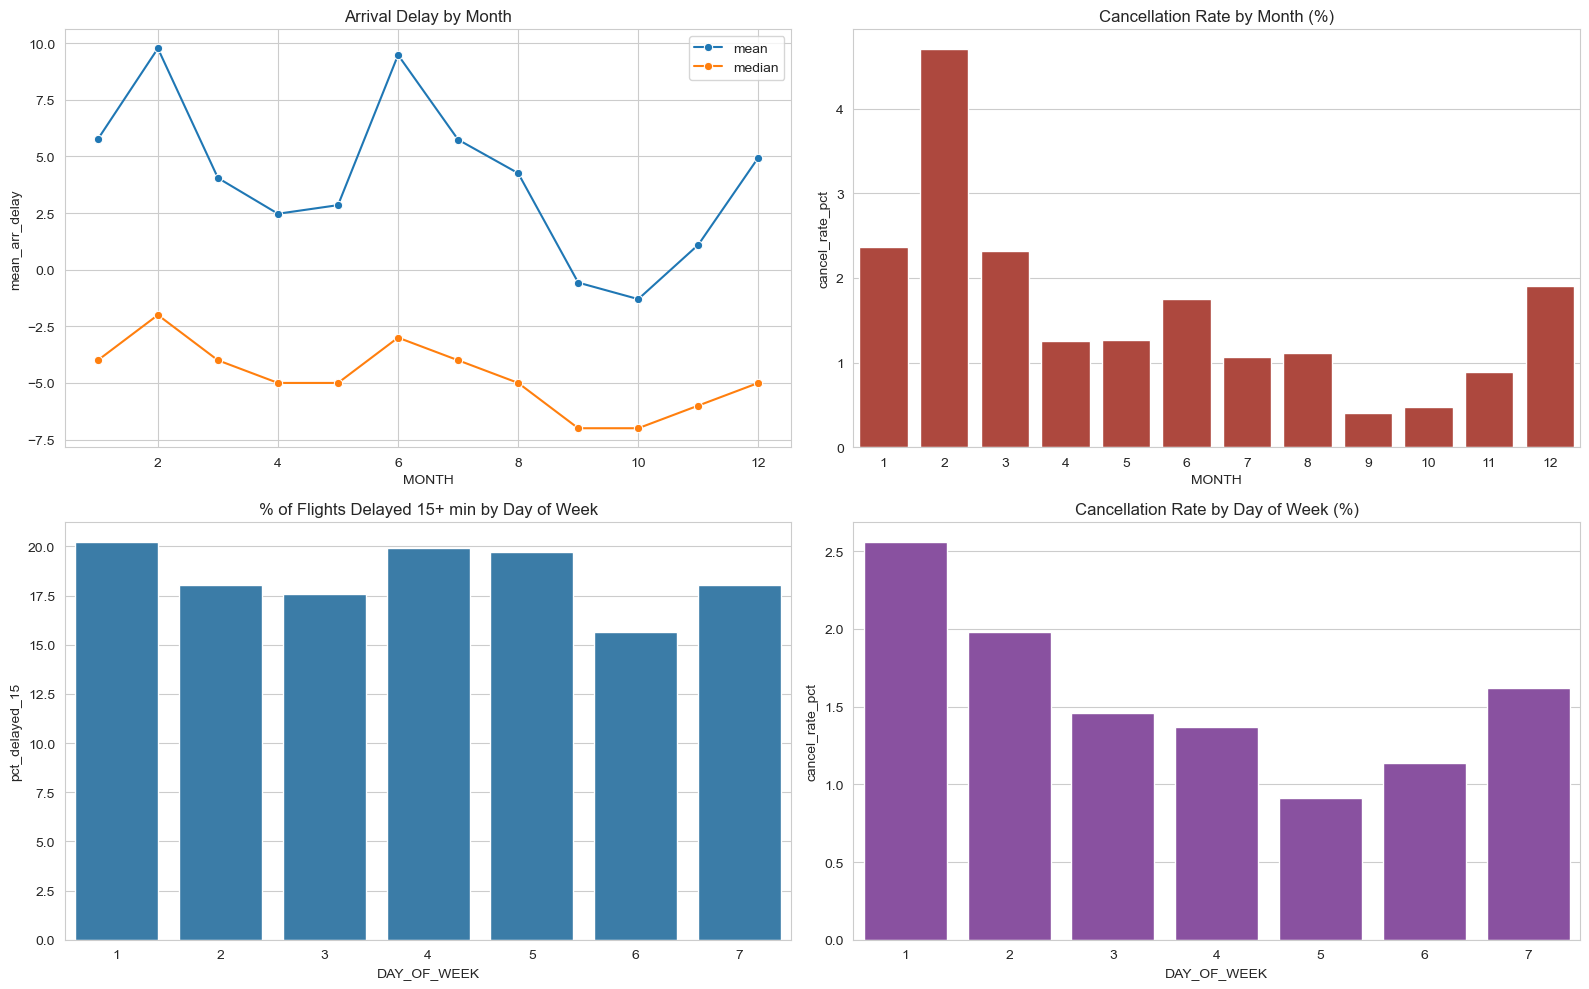

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(x=month_delay.index, y=month_delay['mean_arr_delay'], marker='o', ax=axes[0, 0], label='mean')
sns.lineplot(x=month_delay.index, y=month_delay['median_arr_delay'], marker='o', ax=axes[0, 0], label='median')
axes[0, 0].set_title('Arrival Delay by Month')

sns.barplot(x=month_delay.index, y=month_delay['cancel_rate_pct'], ax=axes[0, 1], color='#c0392b')
axes[0, 1].set_title('Cancellation Rate by Month (%)')

sns.barplot(x=dow_delay.index, y=dow_delay['pct_delayed_15'], ax=axes[1, 0], color='#2980b9')
axes[1, 0].set_title('% of Flights Delayed 15+ min by Day of Week')

sns.barplot(x=dow_delay.index, y=dow_delay['cancel_rate_pct'], ax=axes[1, 1], color='#8e44ad')
axes[1, 1].set_title('Cancellation Rate by Day of Week (%)')

plt.tight_layout()
plt.show()

Step 4: Multivariate Analysis

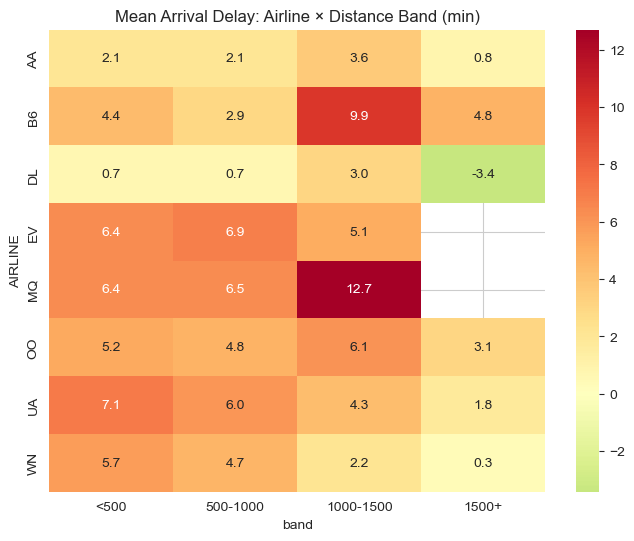

In [58]:
MIN_N = 20   # hide cells backed by fewer flights than this

bands = pd.cut(dff['DISTANCE'], bins=[0, 500, 1000, 1500, 5000],
               labels=['<500', '500-1000', '1000-1500', '1500+'])
top_air = dff['AIRLINE'].value_counts().head(8).index
d = dff[dff['AIRLINE'].isin(top_air)].assign(band=bands)

mean_t = d.pivot_table(index='AIRLINE', columns='band', values='ARRIVAL_DELAY', aggfunc='mean', observed=True)
n_t = d.pivot_table(index='AIRLINE', columns='band', values='ARRIVAL_DELAY', aggfunc='count', observed=True)

plt.figure(figsize=(8, 6))
sns.heatmap(mean_t.where(n_t >= MIN_N), annot=True, fmt='.1f', cmap='RdYlGn_r', center=0)
plt.title('Mean Arrival Delay: Airline × Distance Band (min)')
plt.show()

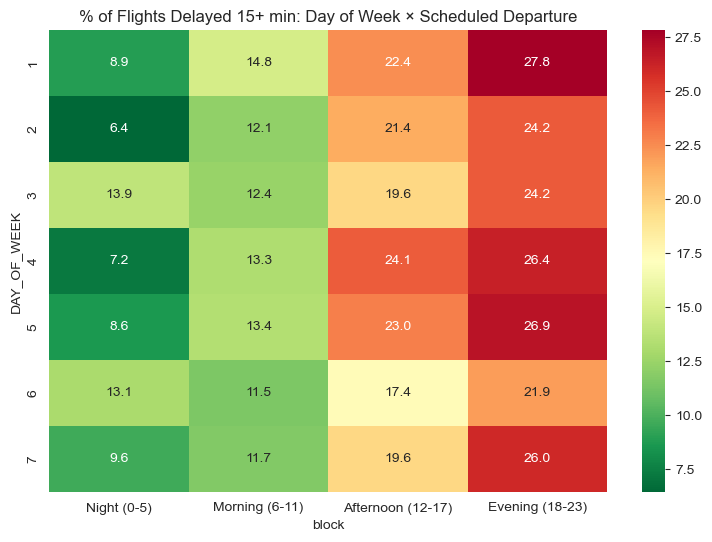

In [59]:
hour_block = pd.cut(dff['SCHEDULED_DEPARTURE'] // 100, bins=[-1, 5, 11, 17, 23],
                    labels=['Night (0-5)', 'Morning (6-11)', 'Afternoon (12-17)', 'Evening (18-23)'])
s = dff.assign(block=hour_block)

pct15 = s.pivot_table(index='DAY_OF_WEEK', columns='block', values='ARRIVAL_DELAY',
                      aggfunc=lambda x: (x.dropna() >= 15).mean() * 100, observed=True)
n_s = s.pivot_table(index='DAY_OF_WEEK', columns='block', values='ARRIVAL_DELAY',
                    aggfunc='count', observed=True)

plt.figure(figsize=(9, 6))
sns.heatmap(pct15.where(n_s >= MIN_N), annot=True, fmt='.1f', cmap='RdYlGn_r')
plt.title('% of Flights Delayed 15+ min: Day of Week × Scheduled Departure')
plt.show()

lead with the time-of-day effect being dominant, Monday evening as the worst cell, and Saturday's advantage holding at every time block.

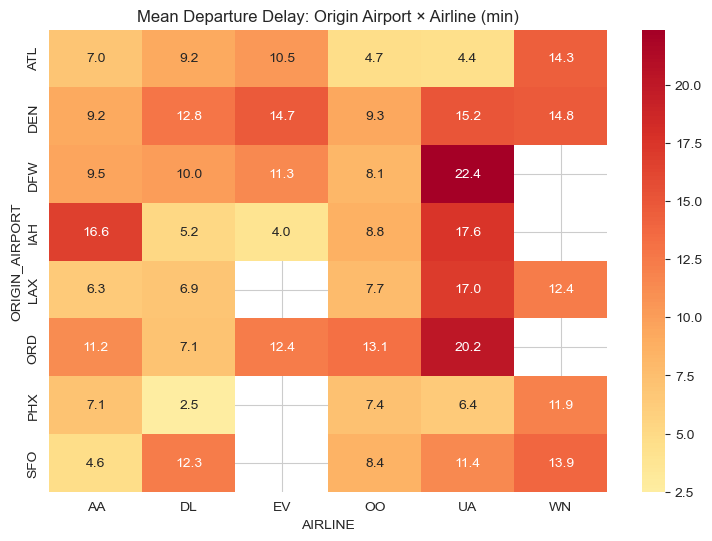

In [60]:
iata = dff[dff['ORIGIN_CODE_FORMAT'] == 'IATA']
top_ap = iata['ORIGIN_AIRPORT'].value_counts().head(8).index
top_al = dff['AIRLINE'].value_counts().head(6).index
a = iata[iata['ORIGIN_AIRPORT'].isin(top_ap) & iata['AIRLINE'].isin(top_al)]

mean_a = a.pivot_table(index='ORIGIN_AIRPORT', columns='AIRLINE', values='DEPARTURE_DELAY', aggfunc='mean', observed=True)
n_a = a.pivot_table(index='ORIGIN_AIRPORT', columns='AIRLINE', values='DEPARTURE_DELAY', aggfunc='count', observed=True)

plt.figure(figsize=(9, 6))
sns.heatmap(mean_a.where(n_a >= MIN_N), annot=True, fmt='.1f', cmap='RdYlGn_r', center=0)
plt.title('Mean Departure Delay: Origin Airport × Airline (min)')
plt.show()

lead with UA's DFW/ORD-specific problem (a finding invisible in the airline-only table), and connect it to the earlier ORD air-system/cancellation findings from Steps 5–7 as a second angle on the same airport.

       AIR_SYSTEM_DELAY  SECURITY_DELAY  AIRLINE_DELAY  LATE_AIRCRAFT_DELAY  \
MONTH                                                                         
1                  2.59            0.02           4.05                 4.45   
2                  3.03            0.00           4.59                 5.89   
3                  2.36            0.00           3.07                 4.23   
4                  2.41            0.01           2.87                 3.28   
5                  2.15            0.01           2.69                 4.05   
6                  3.51            0.00           4.62                 5.66   
7                  2.45            0.01           3.27                 5.29   
8                  2.24            0.03           3.97                 4.02   
9                  1.75            0.00           2.62                 2.42   
10                 1.69            0.02           2.03                 2.45   
11                 2.11            0.04           2.

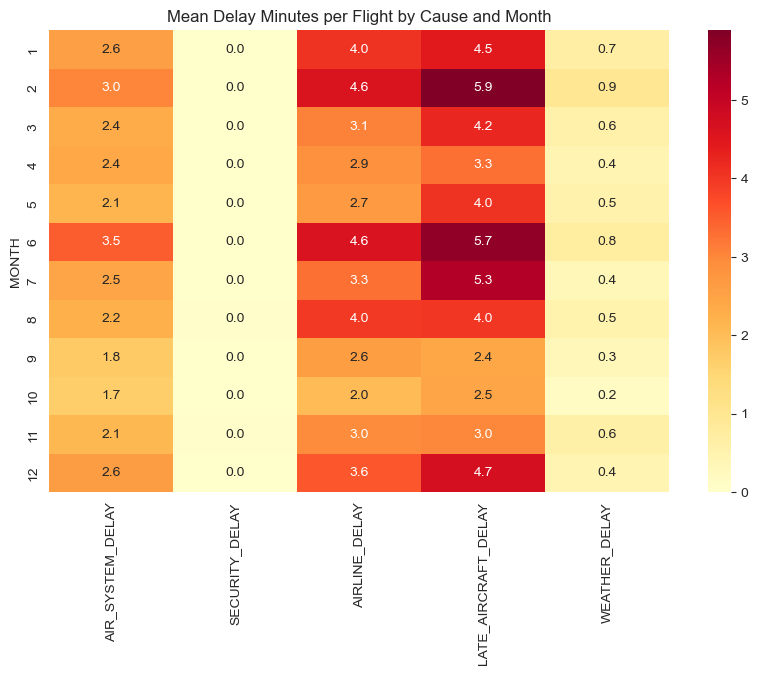

In [61]:
cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
month_cause = dff.groupby('MONTH')[cause_cols].mean().round(2)
print(month_cause)

plt.figure(figsize=(10, 6))
sns.heatmap(month_cause, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Mean Delay Minutes per Flight by Cause and Month')
plt.show()

Late aircraft delay is the leading cause of delay minutes across essentially every month, tying directly back to the departure-vs-arrival finding from Step 3: once a plane is late, it tends to stay late, and that lateness carries into its next flight. The clearest lever from this data is not weather response but turnaround and schedule-buffer management, especially in winter and on the medium-haul routes where MQ and B6 show their worst performance.

Step 5: Group-Based Analysis

In [62]:
reason_summary = (dff[dff['CANCELLED'] == 1]
                   .groupby('CANCELLATION_REASON', observed=True)
                   .agg(cancellations=('FLIGHT_NUMBER', 'size'))
                   .assign(pct_of_cancellations=lambda d: (d['cancellations'] / d['cancellations'].sum() * 100).round(2))
                   .sort_values('cancellations', ascending=False))
reason_summary

,cancellations,pct_of_cancellations
CANCELLATION_REASON,,
B,432,54.41
A,215,27.08
C,146,18.39
D,1,0.13


In [63]:
cancelled = dff[dff['CANCELLED'] == 1]

reason_by_airline = pd.crosstab(cancelled['AIRLINE'], cancelled['CANCELLATION_REASON'])
print(reason_by_airline)

CANCELLATION_REASON   A   B   C  D
AIRLINE                           
AA                   29  70   5  0
AS                    1   1   0  0
B6                    8  21  10  0
DL                    4  25   2  0
EV                   39  57  54  0
F9                    2   3   0  0
HA                    4   0   0  0
MQ                   23  70  37  1
NK                    2   7   2  0
OO                   21  63  11  0
UA                   26  28   5  0
US                    8  20   6  0
VX                    0   0   2  0
WN                   48  67  12  0


Step 6: Pivot Tables

In [64]:
pivot_airline_month = dff.pivot_table(index='AIRLINE', columns='MONTH', values='ARRIVAL_DELAY',
                                       aggfunc='mean', observed=True).round(1)
pivot_airline_month

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
AIRLINE,,,,,,,,,,,,
AA,6.4,11.7,2.9,7.0,0.4,3.5,3.3,4.8,-1.8,-2.8,-2.6,2.2
AS,-1.0,2.1,1.5,-2.4,-4.6,-2.7,-0.5,3.4,-3.7,0.5,-7.3,-0.8
B6,9.5,26.2,4.7,3.7,-0.1,4.8,1.7,7.3,0.5,2.6,-0.6,13.2
DL,-2.2,7.3,1.3,-0.8,-1.4,7.8,0.8,0.4,-2.6,-5.2,-1.9,0.6
EV,7.5,13.0,6.9,4.2,9.3,12.6,4.9,3.0,0.4,2.7,5.9,7.8
F9,18.6,24.4,14.2,12.4,16.4,24.9,10.9,1.7,-1.0,-5.1,12.8,3.0
HA,4.2,5.3,3.0,0.4,-2.2,-0.2,1.8,2.4,1.3,-0.1,1.3,-5.6
MQ,20.3,19.4,11.0,5.2,2.6,13.7,1.9,3.6,0.3,-4.2,1.6,-1.9
NK,7.9,23.4,15.4,5.6,19.5,35.5,13.7,21.9,7.4,11.6,1.0,13.7


In [65]:
iata = dff[dff['ORIGIN_CODE_FORMAT'] == 'IATA']
top_ap = iata['ORIGIN_AIRPORT'].value_counts().head(10).index
cancelled_iata = iata[(iata['CANCELLED'] == 1) & (iata['ORIGIN_AIRPORT'].isin(top_ap))]

pivot_airport_reason = pd.pivot_table(cancelled_iata, index='ORIGIN_AIRPORT', columns='CANCELLATION_REASON',
                                       values='FLIGHT_NUMBER', aggfunc='count', fill_value=0, observed=True)
pivot_airport_reason

CANCELLATION_REASON,A,B,C
ORIGIN_AIRPORT,,,
ATL,3,18,1
DEN,6,13,1
DFW,16,36,0
IAH,1,15,5
LAS,2,3,1
LAX,11,7,3
MSP,5,5,1
ORD,11,43,30
PHX,4,7,0


Step 7: Crosstabs

In [66]:
def severity(x):
    if pd.isna(x): return 'Cancelled/Diverted'
    if x <= 0: return 'Early/On-time'
    if x < 15: return 'Minor delay (<15)'
    return 'Delayed 15+'

dff['DELAY_SEVERITY'] = dff['ARRIVAL_DELAY'].apply(severity)
dff.loc[dff['CANCELLED'] == 1, 'DELAY_SEVERITY'] = 'Cancelled'
dff.loc[(dff['CANCELLED'] == 0) & (dff['DIVERTED'] == 1), 'DELAY_SEVERITY'] = 'Diverted'

ct = pd.crosstab(dff['DAY_OF_WEEK'], dff['DELAY_SEVERITY'], normalize='index').round(3) * 100
ct

DELAY_SEVERITY,Cancelled,Delayed 15+,Diverted,Early/On-time,Minor delay (<15)
DAY_OF_WEEK,,,,,
1,2.6,19.6,0.3,60.4,17.1
2,2.0,17.6,0.2,62.4,17.8
3,1.5,17.3,0.2,63.9,17.1
4,1.4,19.6,0.3,60.3,18.5
5,0.9,19.5,0.1,60.8,18.7
6,1.1,15.4,0.2,67.0,16.2
7,1.6,17.7,0.3,63.4,17.0


In [67]:
mon_cancel = dff[(dff['DAY_OF_WEEK'] == 1) & (dff['CANCELLED'] == 1)]
print(mon_cancel['CANCELLATION_REASON'].value_counts())

CANCELLATION_REASON
B                113
A                 40
C                 37
D                  0
NOT_CANCELLED      0
Name: count, dtype: int64


Step 8: Correlation Analysis

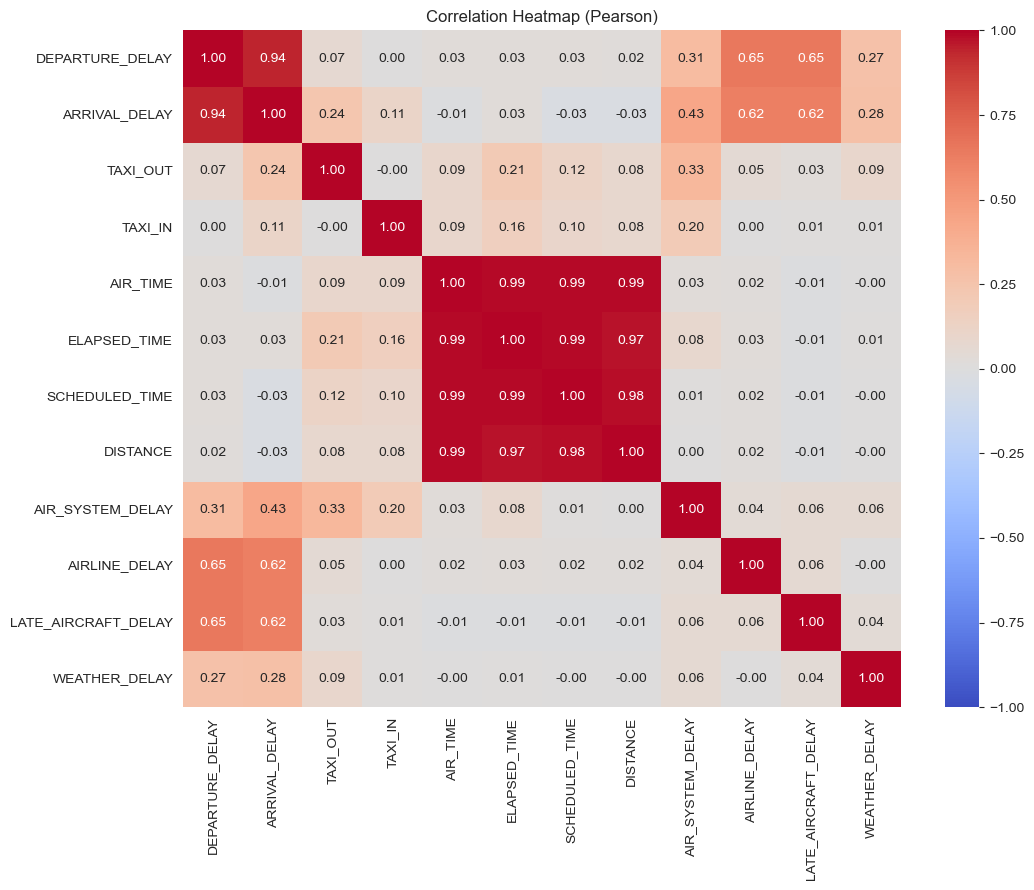

In [68]:
corr_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
             'ELAPSED_TIME', 'SCHEDULED_TIME', 'DISTANCE',
             'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

corr_matrix = dff[corr_cols].corr(method='pearson').round(2)

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Pearson)')
plt.tight_layout()
plt.show()

In [69]:
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index)
pairs.head(15)

AIR_TIME         SCHEDULED_TIME         0.99
                 DISTANCE               0.99
                 ELAPSED_TIME           0.99
ELAPSED_TIME     SCHEDULED_TIME         0.99
SCHEDULED_TIME   DISTANCE               0.98
ELAPSED_TIME     DISTANCE               0.97
DEPARTURE_DELAY  ARRIVAL_DELAY          0.94
                 AIRLINE_DELAY          0.65
                 LATE_AIRCRAFT_DELAY    0.65
ARRIVAL_DELAY    LATE_AIRCRAFT_DELAY    0.62
                 AIRLINE_DELAY          0.62
                 AIR_SYSTEM_DELAY       0.43
TAXI_OUT         AIR_SYSTEM_DELAY       0.33
DEPARTURE_DELAY  AIR_SYSTEM_DELAY       0.31
ARRIVAL_DELAY    WEATHER_DELAY          0.28
dtype: float64

In [70]:
corr_matrix['TAXI_IN'].abs().sort_values(ascending=False)

TAXI_IN                1.00
AIR_SYSTEM_DELAY       0.20
ELAPSED_TIME           0.16
ARRIVAL_DELAY          0.11
SCHEDULED_TIME         0.10
AIR_TIME               0.09
DISTANCE               0.08
LATE_AIRCRAFT_DELAY    0.01
WEATHER_DELAY          0.01
DEPARTURE_DELAY        0.00
TAXI_OUT               0.00
AIRLINE_DELAY          0.00
Name: TAXI_IN, dtype: float64